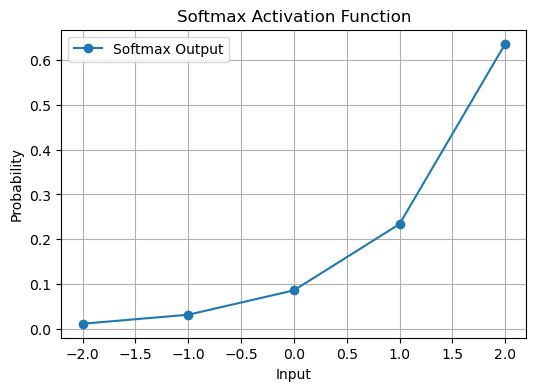

Row sums: [1. 1. 1.]
Predicted Probabilities: [[0.09856589 0.65900114 0.24243297]
 [0.07242256 0.68712609 0.24045136]
 [0.05278319 0.71065899 0.23655783]]
Categorical Cross-Entropy Loss: 1.4946100252727266
Gradient of Loss: [[-0.03957446  0.07036694 -0.03079248]
 [-0.06544874  0.10559315 -0.04014441]]
Adjusted Learning Rate: 0.08333333333333334


In [ ]:
#Program 6: Implement the categorical cross-entropy loss function with both forward and backward passes 
#and verify loss computation.
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    x = np.array(x)
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def categorical_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
    return -np.sum(y_true * np.log(y_pred)) / y_true.shape[0]

def categorical_cross_entropy_derivative(y_true, y_pred):
    return y_pred - y_true

def adjust_learning_rate(initial_lr, epoch):
    return initial_lr * (1 / (1 + 0.1 * (epoch // 10)))

def forward_pass(X, weights):
    y_pred = softmax(np.dot(X, weights))
    print("Row sums:", np.sum(y_pred, axis=1))
    return y_pred

def backward_pass(X, y_true, y_pred, lr):
    grad = categorical_cross_entropy_derivative(y_true, y_pred)
    dW = np.dot(X.T, grad) / X.shape[0]
    return dW * lr

# Data
X = np.array([[1.0, 2.0], [1.5, 2.5], [2.0, 3.0]])
weights = np.array([[0.2, -0.3, 0.5], [-0.5, 0.7, -0.2]])
y_true = np.array([[0,1,0], [1,0,0], [0,0,1]])

# Forward + loss
y_pred = forward_pass(X, weights)
loss = categorical_cross_entropy(y_true, y_pred)

# Backward
update = backward_pass(X, y_true, y_pred, 0.1)

# Outputs (as required)
print("Predicted Probabilities: \n", y_pred)
print("Categorical Cross-Entropy Loss:", loss)
print("Gradient of Loss:", update)

# Learning rate
print("Adjusted Learning Rate:", adjust_learning_rate(0.1, 20))

# Softmax visualization
x_vals = np.array([-2, -1, 0, 1, 2])
plt.plot(x_vals, softmax(x_vals))
plt.title("Softmax")
plt.grid()
plt.show()

In [1]:
#Program  5 Build a simple Artificial Neural Network (ANN) with configurable activation and loss functions. 
#Train the network using activation and loss functions.
import numpy as np

# XOR Dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

def sigmoid(x, derivative=False):
    if derivative:
        return x * (1 - x)
    return 1 / (1 + np.exp(-x))

def initialize_params():
    """Initializes weights with seed 42 to ensure identical results."""
    np.random.seed(42)
    W1 = np.random.randn(2, 4) * 0.5
    b1 = np.zeros((1, 4))
    W2 = np.random.randn(4, 1) * 0.5
    b2 = np.zeros((1, 1))
    return W1, b1, W2, b2

def get_loss_derivative(output, y, loss_type):
    e = 1e-8
    if loss_type == 'mse':
        return (output - y)
    elif loss_type == 'bce':
        return (output - y) / ((output + e) * (1 - output + e))

def train(X, y, lr=0.1, loss_type='mse', epochs=500):
    W1, b1, W2, b2 = initialize_params()
    m = X.shape[0]

    for _ in range(epochs):
        # Forward Pass
        z1 = np.dot(X, W1) + b1
        a1 = sigmoid(z1)
        z2 = np.dot(a1, W2) + b2
        a2 = sigmoid(z2)

        # Backward Pass
        dz2 = get_loss_derivative(a2, y, loss_type) * sigmoid(a2, True)
        dW2 = (1/m) * np.dot(a1.T, dz2)
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)

        da1 = np.dot(dz2, W2.T)
        dz1 = da1 * sigmoid(a1, True)
        dW1 = (1/m) * np.dot(X.T, dz1)
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)

        # Update Parameters
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1
        
    return W1, b1, W2, b2

def get_accuracy(X, y, W1, b1, W2, b2):
    # Final forward pass for prediction
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)
    return np.mean((a2 > 0.5) == y) * 100

# --- Comparison Loops ---

print("--- Learning Rate Comparison ---")
for lr in [0.01, 0.1, 1.0]:
    W1, b1, W2, b2 = train(X, y, lr=lr, loss_type='mse')
    acc = get_accuracy(X, y, W1, b1, W2, b2)
    print(f"LR={lr}, Accuracy={acc:.1f}%")

print("\n--- Loss Function Comparison ---")
for loss in ['mse', 'bce']:
    W1, b1, W2, b2 = train(X, y, lr=0.1, loss_type=loss)
    acc = get_accuracy(X, y, W1, b1, W2, b2)
    print(f"Loss={loss}, Accuracy={acc:.1f}%")

--- Learning Rate Comparison ---
LR=0.01, Accuracy=50.0%
LR=0.1, Accuracy=75.0%
LR=1.0, Accuracy=50.0%

--- Loss Function Comparison ---
Loss=mse, Accuracy=75.0%
Loss=bce, Accuracy=50.0%


In [ ]:
#Program-4 Implement a simple feedforward neural network to demonstrate the impact of different learning 
#rates and activation functions.
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)
X = torch.randn(200, 2)
y = (X[:, 0] + X[:, 1] > 0).float().view(-1, 1)

# Model (just cleaner)
class NN(nn.Module):
    def __init__(self, act):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            act,
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Train
def train(lr, act):
    model = NN(act)
    opt = optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()

    losses = []
    for _ in range(50):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

# ---- Learning Rates ----
for lr in [0.001, 0.01, 0.1]:
    plt.plot(train(lr, nn.ReLU()), label=f"{lr}")

plt.title("Learning Rate (ReLU)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ---- Activations ----
for name, act in [("ReLU", nn.ReLU()), ("Sigmoid", nn.Sigmoid()), ("Tanh", nn.Tanh())]:
    plt.plot(train(0.01, act), label=name)

plt.title("Activation Functions (LR=0.01)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


Gaussian PSNR : 30.96
median : 69.77


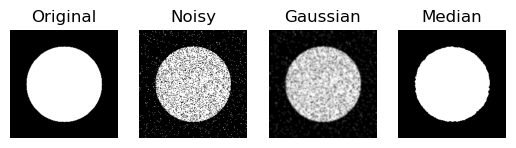

In [3]:
#Program 3Write a Python program to apply various image smoothing techniques on a noisy image using 
#Gaussian Blur and Median Filter and compare the effects.
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.zeros((200,200),dtype=np.uint8)
cv2.circle(img,(100,100),70,255,-1)
noisy = img.copy()
noise = np.random.random(img.shape)
noisy[noise < 0.2] = 0
noisy[noise > 0.98] = 255

gaussian = cv2.GaussianBlur(noisy,(5,5),0)
median = cv2.medianBlur(noisy,5)
titles = ['Original', 'Noisy', 'Gaussian','Median']
images = [img,noisy,gaussian,median]

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(images[i],cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

def psnr(a,b):
    mse = np.mean((a-b)**2)
    return 20*np.log10(255.0/np.sqrt(mse)) if mse else float('inf')

print(f"Gaussian PSNR : {round(psnr(img,gaussian),2)}")
print(f"median : {round(psnr(img,median),2)}")

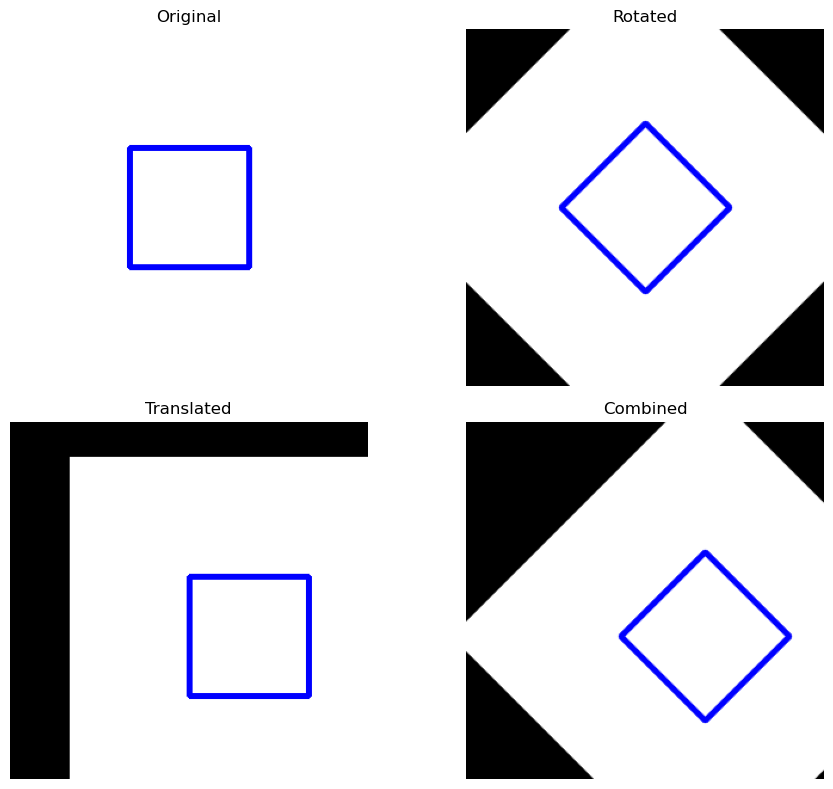

In [4]:
#Program-2 Write a Python program to rotate and translate a given image using affine transformation. Display 
#the original image, rotated image, translated image, and combined rotated and translated image. 
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.ones((300,300,3),dtype=np.uint8)*255
cv2.rectangle(img,(100,100),(200,200),(255,0,0),3)

h,w = img.shape[:2]

#rotation
center = (h//2,w//2)
angle = 45
rot_matrix = cv2.getRotationMatrix2D(center,angle,1)
rotated = cv2.warpAffine(img,rot_matrix,(w,h))

#translation
tx,ty = 50,30
trans_matrix = np.float32([[1,0,tx],[0,1,ty]])
translated = cv2.warpAffine(img,trans_matrix,(w,h))

#combined 
comb_matrix = rot_matrix.copy()
comb_matrix[0,2] += tx
comb_matrix[1,2] += ty
combined = cv2.warpAffine(img,comb_matrix,(w,h))
#plotting
fig,ax = plt.subplots(2,2,figsize=(10,8))
ax[0, 0].imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
ax[0, 0].set_title("Original")

ax[0, 1].imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
ax[0, 1].set_title("Rotated")

ax[1, 0].imshow(cv2.cvtColor(translated, cv2.COLOR_BGR2RGB))
ax[1, 0].set_title("Translated")

ax[1, 1].imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
ax[1, 1].set_title("Combined")

for a in ax.ravel():
    a.axis('off')

plt.tight_layout()
plt.show()

764266
284310
Percentage white: 72.9%


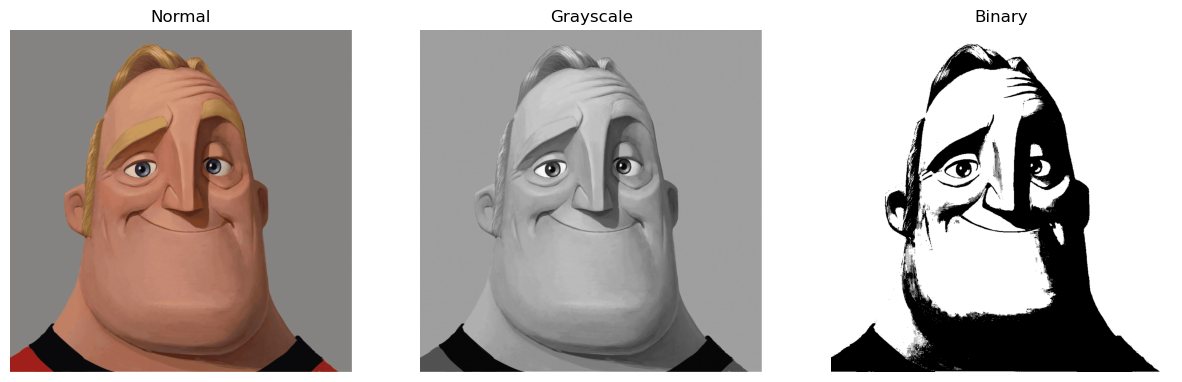

In [6]:
#Program-1 Write a Python program to convert a given color image to grayscale and then to binary using 
#thresholding. Display the original image, grayscale image, and binary image. 
import matplotlib.pyplot as plt
import numpy as np
img = plt.imread('1/inc.jpeg')

r,g,b = img[:,:,0], img[:,:,1], img[:,:,2]
gray = (.299*r + .587*g + .114*b).astype(np.uint8)
threshold = 127
binary = np.where(gray>threshold,255,0)

fig,axes = plt.subplots(1,3,figsize=(15,5))

axes[0].imshow(img)
axes[0].set_title('Normal')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale')

axes[2].imshow(binary,cmap='gray')
axes[2].set_title('Binary')

for ax in axes:
    ax.axis('off')

print(np.sum(binary==255))
print(np.sum(binary==0))
print(f"Percentage white: {np.sum(binary == 255)/binary.size*100:.1f}%")